In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_excel('/content/exercicio_data_cleaning_RL_Base_Erro.xlsx')
df.head()

,preco,temperatura_c,umidade_pct,dia_semana,demanda
0,8,10,85.0,1,170
1,9.3,11.8,81.0,2,187 un
2,10.6,13.6,77.0,3,204
3,11.9,15.4,73.0,4,220
4,"R$ 13,2",17.2,NaN,5,237


#Tratamento e limpeza de Dados

In [136]:
# Verificando se tem valores nulos e os tipos dos dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   preco          120 non-null    object 
 1   temperatura_c  120 non-null    object 
 2   umidade_pct    110 non-null    float64
 3   dia_semana     120 non-null    object 
 4   demanda        120 non-null    object 
dtypes: float64(1), object(4)
memory usage: 4.8+ KB


In [137]:
# Verificando quantos valores nulos tem no dataset

df.isnull().sum()

,0
preco,0
temperatura_c,0
umidade_pct,10
dia_semana,0
demanda,0


In [138]:
# Coluna: preco
def limpar_preco(valor):
    if isinstance(valor, str):
        valor = valor.replace("R$", "").replace(",", ".").strip()
    return float(valor)

df["preco"] = df["preco"].apply(limpar_preco)

In [139]:
# Coluna: temperatura_c
def limpar_temperatura(valor):
    if isinstance(valor, str):
        valor = valor.replace("C", "").replace(",", ".").strip()
    return float(valor)

df["temperatura_c"] = df["temperatura_c"].apply(limpar_temperatura)

In [140]:
# Coluna: demanda
def limpar_demanda(valor):
    if isinstance(valor, str):
        valor = valor.replace("un", "").strip()
    return int(valor)

df["demanda"] = df["demanda"].apply(limpar_demanda)

In [141]:
# Coluna: dia_semana
mapa_dias = {
    "Seg": 1, "Ter": 2, "Qua": 3, "Qui": 4,
    "Sex": 5, "Sab": 6, "Dom": 7
}

def limpar_dias(valor):
    if isinstance(valor, str):
        return mapa_dias.get(valor.strip(), np.nan)
    return int(valor)

df["dia_semana"] = df["dia_semana"].apply(limpar_dias)

In [142]:
# Coluna: umidade_pct
df["umidade_pct"] = df["umidade_pct"].where(
    df["umidade_pct"].between(0, 100), other=np.nan
)

#Imputação dos NaNs pela mediana
mediana_umidade = df["umidade_pct"].median()
df["umidade_pct"] = df["umidade_pct"].fillna(mediana_umidade)

print(f"\nMediana usada para imputar umidade_pct: {mediana_umidade:.2f}")


Mediana usada para imputar umidade_pct: 58.90


In [143]:
# Verificação Final
print("\nShape após limpeza:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nValores nulos restantes:")
print(df.isnull().sum())
print("\nEstatísticas descritivas:")
print(df.describe())


Shape após limpeza: (120, 5)

Tipos de dados:
preco            float64
temperatura_c    float64
umidade_pct      float64
dia_semana         int64
demanda            int64
dtype: object

Valores nulos restantes:
preco            0
temperatura_c    0
umidade_pct      0
dia_semana       0
demanda          0
dtype: int64

Estatísticas descritivas:
            preco  temperatura_c  umidade_pct  dia_semana     demanda
count  120.000000     120.000000   120.000000  120.000000  120.000000
mean    14.400000      20.800000    59.156667    3.975000  246.066667
std      3.765612       6.266357    12.949298    2.018663   63.727062
min      8.000000      10.000000    35.600000    1.000000   96.000000
25%     11.175000      15.400000    49.250000    2.000000  199.000000
50%     14.400000      20.800000    58.900000    4.000000  247.000000
75%     17.625000      26.200000    68.950000    6.000000  293.250000
max     20.800000      31.600000    85.000000    7.000000  381.000000


#Análises

In [144]:
# Visualizando as 5 primeiras linhas

df.head()

,preco,temperatura_c,umidade_pct,dia_semana,demanda
0,8.0,10.0,85.0,1,170
1,9.3,11.8,81.0,2,187
2,10.6,13.6,77.0,3,204
3,11.9,15.4,73.0,4,220
4,13.2,17.2,58.9,5,237


In [145]:
#Temperatura com maior de demanda de sorvetes

df.groupby('temperatura_c')['demanda'].mean().sort_values(ascending=False).head()

,demanda
temperatura_c,
31.0,381.0
29.2,365.0
24.6,363.0
28.4,352.0
27.4,348.0


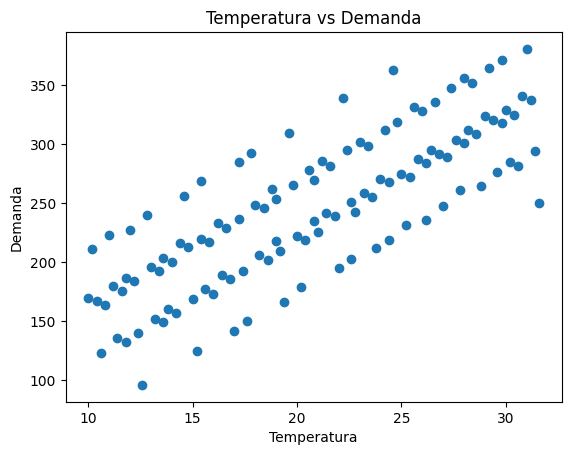

In [180]:
# Visualização da relação entre Umidade e Demanda

plt.scatter(df['temperatura_c'], df['demanda'])
plt.title("Temperatura vs Demanda")
plt.xlabel("Temperatura")
plt.ylabel("Demanda")
plt.show()

In [146]:
# Dias da semana com maiores demandas por sorvete

df.groupby('dia_semana')['demanda'].mean().sort_values(ascending=False)

,demanda
dia_semana,
7,284.529412
6,266.294118
5,258.411765
4,246.294118
3,238.529412
2,220.176471
1,210.333333


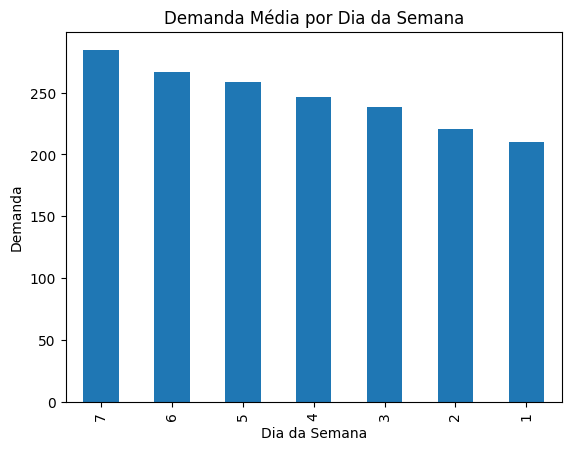

In [178]:
# Visualização da relação entre Dia da Semana e Demanda

df.groupby('dia_semana')['demanda'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Demanda Média por Dia da Semana")
plt.ylabel("Demanda")
plt.xlabel("Dia da Semana")
plt.show()

In [148]:
# Umidade com maior Demanda de sorvete

df.groupby('umidade_pct')['demanda'].mean().sort_values(ascending=False).head()

,demanda
umidade_pct,
37.4,381.0
41.0,372.0
41.4,365.0
52.4,363.0
45.0,356.0


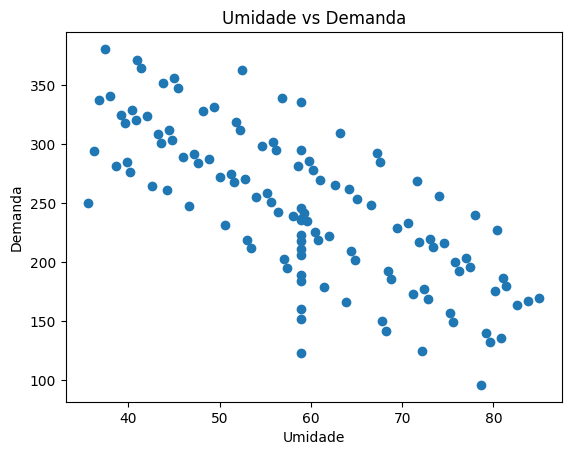

In [181]:
# Visualização da relação entre Umidade e Demanda

plt.scatter(df['umidade_pct'], df['demanda'])
plt.title("Umidade vs Demanda")
plt.xlabel("Umidade")
plt.ylabel("Demanda")
plt.show()

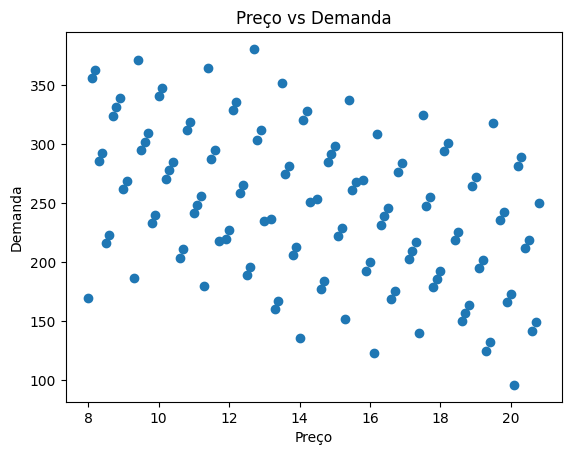

Correlação: -0.4326776607573998


In [179]:
# Relação entre Preço e Demanda

plt.scatter(df['preco'], df['demanda'])
plt.title("Preço vs Demanda")
plt.xlabel("Preço")
plt.ylabel("Demanda")
plt.show()

print("Correlação:", df['preco'].corr(df['demanda']))

In [182]:
# Matriz de Correlação

correlacao = df[['preco', 'temperatura_c', 'umidade_pct', 'demanda']].corr()
print(correlacao)

                  preco  temperatura_c  umidade_pct   demanda
preco          1.000000       0.049786    -0.025540 -0.432678
temperatura_c  0.049786       1.000000    -0.924544  0.794570
umidade_pct   -0.025540      -0.924544     1.000000 -0.738423
demanda       -0.432678       0.794570    -0.738423  1.000000


#Insights da Análises

Na etapa de Análise Exploratória de Dados (EDA), foi possível identificar que a variável demanda apresenta variações relevantes ao longo do conjunto de dados, indicando que não se trata de um comportamento constante, mas sim influenciado por fatores externos. Entre esses fatores, o preço demonstrou uma relação inversa com a demanda, sugerindo que o produto possui certa elasticidade, ou seja, aumentos no preço tendem a reduzir o volume consumido. Além disso, a temperatura mostrou um impacto positivo na demanda, indicando que dias mais quentes favorecem o aumento do consumo, o que pode estar relacionado à natureza do produto analisado. Por outro lado, a umidade apresentou uma influência potencialmente negativa, sugerindo que condições climáticas menos confortáveis podem reduzir a procura. De forma geral, a análise evidenciou que a demanda é fortemente impactada por variáveis externas, especialmente preço e clima, e que os dados estão adequados para análises mais avançadas e construção de modelos preditivos.


#Regressão Linear

In [149]:
# Separar Features e Target
X = df[["preco", "temperatura_c", "umidade_pct", "dia_semana"]]
y = df["demanda"]

In [183]:
# Dividir em treino e teste (80/20)
X_train, X_test, y_train, y_teste = train_test_split(X, y, test_size=0.2,random_state=42)

print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Treino: 96 amostras | Teste: 24 amostras


In [184]:
# Treinar o Modelo
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [185]:
# Predizer e Avaliar
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== MÉTRICAS DE AVALIAÇÃO ===")
print(f"R²    : {r2:.4f}")
print(f"MAE   : {mae:.2f} unidades")
print(f"RMSE  : {rmse:.2f} unidades")


=== MÉTRICAS DE AVALIAÇÃO ===
R²    : 0.9998
MAE   : 0.70 unidades
RMSE  : 0.80 unidades


#Insights do Modelo

O modelo de regressão apresentou um desempenho excepcional, sendo capaz de explicar praticamente toda a variação da demanda (R² = 0,9998) e com erros mínimos de previsão, o que indica uma altíssima precisão nas estimativas. Na prática, isso significa que as variáveis analisadas (especialmente preço e temperatura) conseguem prever a demanda com grande confiabilidade. No entanto, um resultado próximo do perfeito gera uma atenção importante: pode haver overfitting. Ainda assim, o modelo se mostra extremamente promissor como ferramenta estratégica.

#Conclusão Final

Ao longo do projeto, foi possível transformar um dataset inicialmente desorganizado em uma base confiável, permitindo análises consistentes e a construção de um modelo preditivo eficiente. A análise exploratória mostrou que a demanda não é aleatória, sendo fortemente influenciada por fatores como preço e condições climáticas, principalmente a temperatura. O modelo de regressão reforçou esses padrões e apresentou alta precisão nas previsões, indicando que essas variáveis são bons indicadores do comportamento da demanda. No geral, o estudo demonstra que é possível utilizar dados para entender melhor o consumo e apoiar decisões mais estratégicas, como definição de preços e planejamento de vendas, desde que o modelo seja validado para garantir sua aplicação em cenários reais.